GenAI (GPT-5 and GEMINI) has been used to do this project as a helping tool. This project has been created only by Roberto Punzano, without the help of any other human.

## 0. Importing Libraries and Dataset

In [ ]:
import pandas as pd
import numpy as np
import json #saving files
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer #DitilBERT and fine-tuning
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt   #visualizing plots
import seaborn as sns   #prettier plotting
import torch as tc  #tensor computation and GPU handling
import numpy as np
from datasets import load_dataset   #creating a DataSet object
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
#Loading the dataset and filtring it

dataset_full = load_dataset("clapAI/MultiLingualSentiment", split="train")  #we load the full dataset
dataset_es = dataset_full.filter(lambda x: x['language'] == 'es')   #we filter the Spanish dataset
print(dataset_es)
df = dataset_es.to_pandas()[['label', 'text']]

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/228M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/314M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/99.1M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/3147478 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/393435 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/393436 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3147478 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'source', 'domain', 'language'],
    num_rows: 178434
})


## 1. Creating the Training, Validation and Test Sets

In [ ]:
dataset_small = dataset_es.shuffle(seed=42).select(range(5000))

dataset_train_test = dataset_small.train_test_split(test_size=0.2, seed=42)  #splitting the first set into train (80%) and provisional test (20%)
dataset_dev_test = dataset_train_test['test'].train_test_split(test_size=0.5, seed=42)

#Final DataSets
train_set = dataset_train_test['train']
dev_set = dataset_dev_test['train']
test_set = dataset_dev_test['test']

print(f"Train: {len(train_set)}, Dev: {len(dev_set)}, Test: {len(test_set)}")

Train: 4000, Dev: 500, Test: 500


In [ ]:
label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

def encode_labels(example):
  """This function encodes negative, positive and neutral into digits for data processing"""
    example["label"] = label2id[example["label"]]
    return example

train_set = train_set.map(encode_labels)
dev_set = dev_set.map(encode_labels)
test_set = test_set.map(encode_labels)

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

## 2. Tokenizer and Model Configuration

In [ ]:
#Loading the Tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-multilingual-cased")
sentence = "Buena compra Tiene el tamaño perfecto. Fácil de limpiar y su uso doble es genial."
tokens_sentence = tokenizer(sentence)
print(tokens_sentence)

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'input_ids': [101, 71436, 50753, 32005, 10125, 29098, 43477, 10133, 119, 143, 60074, 10161, 10104, 11614, 58150, 10129, 193, 10198, 13829, 29783, 10196, 107282, 10415, 119, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [ ]:
def tokenize(batch):
    """This function tokenizes and regulates sentences (by truncating them or adding paddings [0])"""

    textos = [str(text) for text in batch['text']] #in case of NaN, converting to string so that the tokenizer can read it

    return tokenizer(
        textos,
        padding='max_length',
        truncation=True,
        max_length=128
    )

sentence = "Buena compra Tiene el tamaño perfecto. Fácil de limpiar y su uso doble es genial."
tokenized_example = tokenize({'text': [sentence]})

print(f"Sentence: {sentence}")
print(f"Tokens: {tokenized_example.keys()}")

Sentence: Buena compra Tiene el tamaño perfecto. Fácil de limpiar y su uso doble es genial.
Tokens: KeysView({'input_ids': [[101, 71436, 50753, 32005, 10125, 29098, 43477, 10133, 119, 143, 60074, 10161, 10104, 11614, 58150, 10129, 193, 10198, 13829, 29783, 10196, 107282, 10415, 119, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
#Tokenizing all sets with the .map() function from Hugging Face datasets library
tokenized_train = train_set.map(tokenize, batched=True)
tokenized_dev = dev_set.map(tokenize, batched=True)
tokenized_test = test_set.map(tokenize, batched=True)

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [ ]:
#Transforming tokenized datasets into PyTorch tensors
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_dev = tokenized_dev.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

tokenized_train.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
tokenized_dev.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
tokenized_test.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

In [ ]:
print(tokenized_train[0]['labels'])

tensor(2)


In [ ]:
#Structure of the datasets
print(tokenized_train)
print(tokenized_dev)

Dataset({
    features: ['text', 'labels', 'source', 'domain', 'language', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 4000
})
Dataset({
    features: ['text', 'labels', 'source', 'domain', 'language', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 500
})


In [ ]:
#Loading a Sequence Classification Pretrained Model based on DistilBERT
hs_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-multilingual-cased",
    num_labels=3    #Three Class Classification
)

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 3. Model Performance in Training and Validation Sets

In [ ]:
#Initializing Arguments for Settings for the Training Model
training_args = TrainingArguments(
    per_device_train_batch_size=8,   #Taking batches from 16 to 16 (optimized for GPU memory and training stability)
    gradient_accumulation_steps=2,
    learning_rate=2e-5,   #Gradient Descent Steps
    num_train_epochs=3,   #Three epochs to avoid Overfitting
    eval_strategy="epoch",
    logging_steps=50,  #Log Training Metrics every 50 Steps
    fp16=True,     #Speed Up Training and GPU Optimization
    save_strategy="epoch",
    load_best_model_at_end=True, #This takes the best epoch for the model (avoiding imprecision or overfitting)
    metric_for_best_model="eval_loss", #Choosing loss instead of accuracy to be more precise
    save_total_limit=2    #Limiting 2 Savings
)

In [ ]:
#Fitting the Train Set: Connecting the model, the data and the training configuration
trainer = Trainer(
    model=hs_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_dev,
)

In [ ]:
#Showing GPU
print(tc.cuda.is_available())
print(tc.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
#Training the Model

trainer.train()

Epoch,Training Loss,Validation Loss
1,1.451055,0.701349
2,1.120179,0.684241
3,1.010775,0.691446


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=750, training_loss=1.3063895467122395, metrics={'train_runtime': 201.7723, 'train_samples_per_second': 59.473, 'train_steps_per_second': 3.717, 'total_flos': 397409283072000.0, 'train_loss': 1.3063895467122395, 'epoch': 3.0})

Metrics for TRAIN set
Precision: 0.768
Recall:    0.725
F1:        0.725
Confusion Matrix:
[[1505   71   37]
 [ 296  251  243]
 [  63   60 1474]]


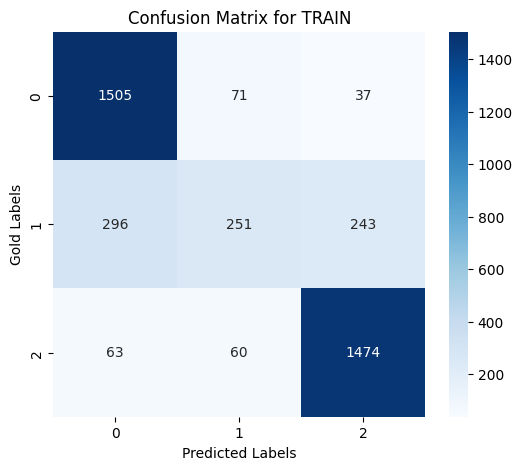

Metrics for DEV set
Precision: 0.645
Recall:    0.630
F1:        0.624
Confusion Matrix:
[[167  12  21]
 [ 42  19  30]
 [ 18  14 177]]


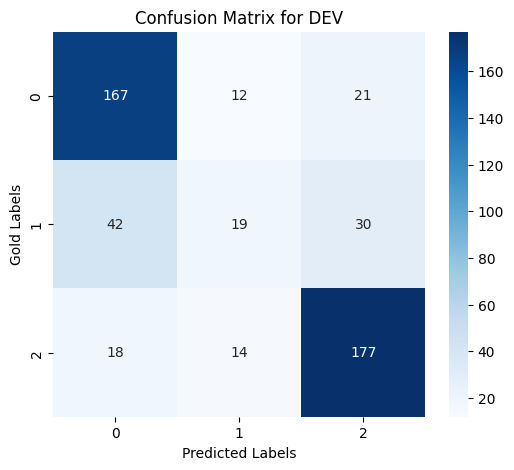

In [ ]:
#Computing and saving Metrics
def evaluate_model(trainer, tokenized_dataset, dataset_name="dev", save_path=None):
    """
    Computes precision, recall, F1, and confusion matrix
    for a given dataset using the HuggingFace Trainer predictions.
    """
    #Getting model predictions
    predictions_output = trainer.predict(tokenized_dataset)

    y_pred = predictions_output.predictions.argmax(axis=1)  #predicted labels
    y_gold = predictions_output.label_ids   #true labels

    #Computing metrics
    precision = precision_score(y_gold, y_pred, average='macro')  #average macro takes the mean of all rates
    recall = recall_score(y_gold, y_pred, average='macro')
    f1 = f1_score(y_gold, y_pred, average='macro')
    cm = confusion_matrix(y_gold, y_pred)

    #Printing metrics
    print(f"Metrics for {dataset_name.upper()} set")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1:        {f1:.3f}")
    print("Confusion Matrix:")
    print(cm)

    #Plotting confusion matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Labels')
    plt.ylabel('Gold Labels')
    plt.title(f'Confusion Matrix for {dataset_name.upper()}')
    plt.show()

    return precision, recall, f1, cm

#Running the function for train and dev sets
train_metrics = evaluate_model(trainer, tokenized_train, dataset_name="train", save_path="train_metrics.json")
dev_metrics   = evaluate_model(trainer, tokenized_dev, dataset_name="dev", save_path="dev_metrics.json")


## 4. Test Set

In [ ]:
# Running the Test Set
predictions_output = trainer.predict(tokenized_test)

In [ ]:
#Get predicted classes
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_gold = predictions_output.label_ids

print("Predictions:", y_pred)
print("Gold labels:", y_gold)

#Confusion matrix
cm = confusion_matrix(y_gold, y_pred)
print("Confusion matrix:\n", cm)

#Compute metrics
precision = precision_score(y_gold, y_pred, average='macro')
recall = recall_score(y_gold, y_pred, average='macro')
f1 = f1_score(y_gold, y_pred, average='macro')

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1:        {f1:.3f}")

Predictions: [0 0 1 2 2 0 2 2 0 2 0 0 2 2 2 1 2 2 0 2 0 2 1 2 2 2 2 0 1 2 2 1 2 1 0 0 2
 0 0 2 2 0 2 0 2 2 2 1 2 2 1 2 2 2 2 2 2 0 2 2 0 0 2 2 2 1 0 2 2 0 2 0 0 0
 0 0 2 0 2 0 0 0 2 2 2 2 1 2 0 0 0 2 1 2 2 0 2 0 2 2 2 2 0 2 0 1 1 0 2 0 0
 0 0 2 0 0 0 0 2 2 2 0 2 0 2 2 0 1 1 0 2 2 0 2 0 2 0 0 0 2 2 0 2 0 2 0 1 0
 2 2 2 2 0 0 1 0 0 2 2 2 0 0 0 0 2 2 2 2 2 2 2 2 0 2 2 0 2 0 0 0 2 0 0 2 0
 2 0 2 2 0 0 2 0 2 2 0 2 1 0 0 0 2 0 0 0 2 0 0 0 2 0 2 0 2 2 2 0 2 0 2 0 2
 0 2 0 0 2 2 0 2 0 1 0 1 2 0 0 0 2 0 2 2 0 2 2 0 2 0 2 0 0 0 2 2 1 0 2 2 0
 1 0 1 2 0 2 1 2 0 0 2 1 1 2 2 0 2 0 2 2 2 2 0 0 0 2 0 1 1 0 0 0 2 2 1 0 0
 2 0 0 2 2 0 2 0 0 0 1 0 0 2 2 2 1 0 0 2 0 2 2 0 0 0 0 0 0 2 0 2 0 2 2 1 2
 2 0 0 0 2 2 0 2 0 0 2 0 2 0 0 0 0 2 2 0 2 0 0 2 0 0 2 0 0 2 2 0 0 0 0 1 0
 1 2 1 2 2 0 0 2 2 1 0 1 2 0 1 2 2 2 0 1 0 2 0 0 0 2 2 1 0 0 2 0 0 0 2 2 0
 2 0 2 0 2 2 2 0 1 0 2 2 0 0 2 2 0 2 2 0 2 2 2 0 2 0 2 2 2 2 0 2 0 0 0 2 0
 0 0 2 2 2 2 0 2 2 0 0 2 0 0 1 0 2 0 0 2 0 2 0 2 2 2 1 0 0 0 2 0 2 0 0 2 2
 2 2 2 2 0 2

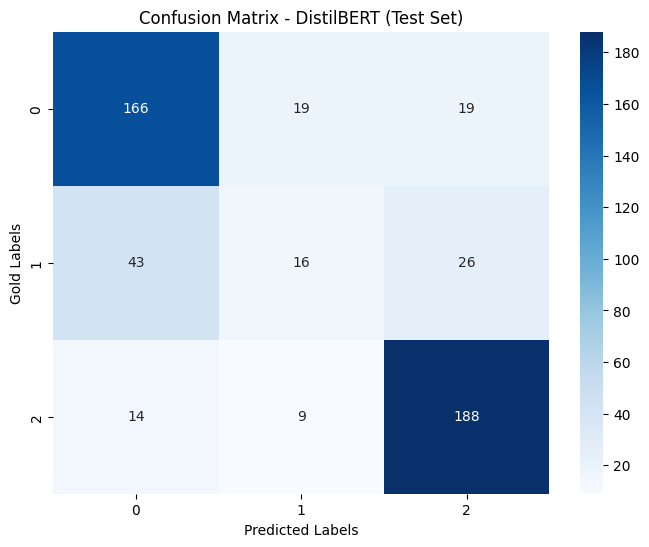

In [ ]:
# Visualizing Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('Gold Labels')
plt.title('Confusion Matrix - DistilBERT (Test Set)')
plt.show()

## 5. Linguistic Analysis of Model Errors

In [ ]:
def deep_error_audit(df_errors, num_examples=5):
    """
    This function takes errors from the three classes (positive, negative and neutral) for linguistic analysis.
    """
    #Types of mistakes
    optimistic = df_errors[(df_errors['real_label'] == 0) & (df_errors['predicted_label'] == 2)]  #it was negative but the model graded it positively
    pessimistic = df_errors[(df_errors['real_label'] == 2) & (df_errors['predicted_label'] == 0)] #it was positive but the model graded it negatively
    confused = df_errors[(df_errors['real_label'] == 1) & (df_errors['predicted_label'] != 1)]    #it was neutral but the model was confused and went to the extremes

    categories = [
        ("OPTIMISTIC CASES (Real: Negative -> Pred: Positive)", optimistic),
        ("PESSIMISTIC CASES (Real: Positive -> Pred: Negative)", pessimistic),
        ("THE NEUTRAL LIMBO (Intensity/Nuance Confusion)", confused)
    ]

    for title, dataset in categories:
        print(f"\n{'#'*75}")
        print(f" {title} - Total detected: {len(dataset)}")
        print(f"{'#'*75}")

        if len(dataset) == 0:
            print("No examples found in this category.")
            continue

        # Take random samples (or all if less than num_examples)
        sample_size = min(num_examples, len(dataset))
        sample = dataset.sample(sample_size, random_state=42)

        for idx, row in sample.iterrows():
            # Data cleaning for display
            text_clean = " ".join(str(row['text']).split())
            summary = (text_clean[:500] + " [...]") if len(text_clean) > 500 else text_clean

            # Visual mapping for readability
            label_map = {0: "NEG", 1: "NEU", 2: "POS"}
            real_str = label_map.get(row['real_label'])
            pred_str = label_map.get(row['predicted_label'])

            print(f"\n[ID: {idx}] | Real: {real_str} | Pred: {pred_str}")
            print(f"TEXT: {summary}")
            print("-" * 60)

In [ ]:
predictions_output = trainer.predict(tokenized_dev)
df_errors = pd.DataFrame({
    'text': dev_set['text'],
    'real_label': predictions_output.label_ids,
    'predicted_label': predictions_output.predictions.argmax(axis=1)
})
deep_error_audit(df_errors)


###########################################################################
 OPTIMISTIC CASES (Real: Negative -> Pred: Positive) - Total detected: 12
###########################################################################

[ID: 345] | Real: NEG | Pred: POS
TEXT: Yo sabía que la #SuperLuna traería efectos negativos #supermoonfail
------------------------------------------------------------

[ID: 317] | Real: NEG | Pred: POS
TEXT: Estos días me he soñado con el accidente varias veces Increíble el trauma que generan estas cosas!
------------------------------------------------------------

[ID: 1] | Real: NEG | Pred: POS
TEXT: Es muy importante q fijé o se adhiera bien fuerte No fija lo suficiente a pesar de que los más grande tienen buen tamaño
------------------------------------------------------------

[ID: 298] | Real: NEG | Pred: POS
TEXT: calidad bajita mucho mas gruesas de lo que me esperaba
------------------------------------------------------------

[ID: 172] | Real: NEG |